Crop-to-ink method

In [42]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [43]:
def load_bhsig(root_path, script_type):
    records = []
    for writer_folder in sorted(os.listdir(root_path)):
        writer_path = os.path.join(root_path, writer_folder)
        if not os.path.isdir(writer_path):
            continue

        for fname in os.listdir(writer_path):
            if not fname.lower().endswith(".tif"):
                continue

            # Example: H-S-160-F-16.tif
            parts = fname.split("-")
            if len(parts) < 5:
                continue

            writer_num = int(parts[2])               # 160
            gf = parts[3].upper()                    # G or F
            sample_id = int(parts[4].split(".")[0])  # 16

            label = "genuine" if gf == "G" else "forgery"

            records.append({
                "dataset": f"BHSIG_{script_type}",
                "writer_id": f"BHSIG_{script_type}_{writer_num:03d}",
                "sample_id": sample_id,
                "label": label,
                "path": os.path.join(writer_path, fname)
            })

    return pd.DataFrame(records)

bengali_path = r"W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\BHSig260\BHSig260-Bengali"
hindi_path   = r"W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\BHSig260\BHSig260-Hindi"

valid_bhsig_b = load_bhsig(bengali_path, "B")
valid_bhsig_h = load_bhsig(hindi_path, "H")
valid_bhsig = pd.concat([valid_bhsig_b, valid_bhsig_h], ignore_index=True)

print("Total images:", len(valid_bhsig))
print(valid_bhsig["label"].value_counts())
print("Unique writers:", valid_bhsig["writer_id"].nunique())
display(valid_bhsig.head())

Total images: 14040
label
forgery    7800
genuine    6240
Name: count, dtype: int64
Unique writers: 260


,dataset,writer_id,sample_id,label,path
0,BHSIG_B,BHSIG_B_001,1,forgery,W:\SRH study\Case Study 2\Offline Signature Ve...
1,BHSIG_B,BHSIG_B_001,2,forgery,W:\SRH study\Case Study 2\Offline Signature Ve...
2,BHSIG_B,BHSIG_B_001,3,forgery,W:\SRH study\Case Study 2\Offline Signature Ve...
3,BHSIG_B,BHSIG_B_001,4,forgery,W:\SRH study\Case Study 2\Offline Signature Ve...
4,BHSIG_B,BHSIG_B_001,5,forgery,W:\SRH study\Case Study 2\Offline Signature Ve...


In [32]:
def split_writers(valid_df, train_ratio=0.7, val_ratio=0.15, seed=42):
    writers = np.array(sorted(valid_df["writer_id"].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(writers)

    n = len(writers)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))

    train_w = set(writers[:n_train])
    val_w   = set(writers[n_train:n_train+n_val])
    test_w  = set(writers[n_train+n_val:])

    return train_w, val_w, test_w

train_writers, val_writers, test_writers = split_writers(valid_bhsig, seed=42)

print("Train writers:", len(train_writers))
print("Val writers:", len(val_writers))
print("Test writers:", len(test_writers))
print("Overlap train-val:", len(train_writers & val_writers))
print("Overlap train-test:", len(train_writers & test_writers))
print("Overlap val-test:", len(val_writers & test_writers))

Train writers: 182
Val writers: 39
Test writers: 39
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [33]:
def build_pools(df_subset):
    genuine_by_writer = {}
    forgery_by_writer = {}
    for wid, group in df_subset.groupby("writer_id"):
        g = group[group["label"] == "genuine"]["path"].tolist()
        f = group[group["label"] == "forgery"]["path"].tolist()
        if len(g) > 0: genuine_by_writer[wid] = g
        if len(f) > 0: forgery_by_writer[wid] = f
    return genuine_by_writer, forgery_by_writer

def generate_pairs_for_writers(valid_df, writer_set, n_pairs=80000, seed=1, neg_mix=0.9):
    """
    label=1: genuine-genuine same writer (positive)
    label=0: negative (mostly genuine-forgery same writer + some cross-writer genuine-genuine)
    neg_mix: fraction of negatives that are same-writer genuine-forgery
    """
    df_subset = valid_df[valid_df["writer_id"].isin(writer_set)].copy()
    genuine_by_writer, forgery_by_writer = build_pools(df_subset)

    writers = sorted(genuine_by_writer.keys())
    rng = np.random.default_rng(seed)

    n_pos = n_pairs // 2
    n_neg = n_pairs - n_pos
    n_neg_same  = int(round(n_neg * neg_mix))
    n_neg_cross = n_neg - n_neg_same

    writers_with_forg = sorted(set(genuine_by_writer) & set(forgery_by_writer))
    if len(writers) < 2:
        raise ValueError("Need >=2 writers.")
    if len(writers_with_forg) == 0:
        raise ValueError("Need writers with both genuine and forgery.")

    pairs = []

    # positives
    for _ in range(n_pos):
        w = rng.choice(writers)
        g = genuine_by_writer[w]
        a, b = rng.choice(len(g), size=2, replace=False)
        pairs.append({"path_a": g[a], "path_b": g[b], "label": 1})

    # negatives same-writer (genuine vs forgery)
    for _ in range(n_neg_same):
        w = rng.choice(writers_with_forg)
        g = genuine_by_writer[w]
        f = forgery_by_writer[w]
        a = rng.integers(0, len(g))
        b = rng.integers(0, len(f))
        pairs.append({"path_a": g[a], "path_b": f[b], "label": 0})

    # negatives cross-writer (genuine vs genuine)
    for _ in range(n_neg_cross):
        w1, w2 = rng.choice(writers, size=2, replace=False)
        g1 = genuine_by_writer[w1]
        g2 = genuine_by_writer[w2]
        a = rng.integers(0, len(g1))
        b = rng.integers(0, len(g2))
        pairs.append({"path_a": g1[a], "path_b": g2[b], "label": 0})

    df_pairs = pd.DataFrame(pairs).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df_pairs

train_pairs = generate_pairs_for_writers(valid_bhsig, train_writers, n_pairs=80000, seed=1, neg_mix=0.9)
val_pairs   = generate_pairs_for_writers(valid_bhsig, val_writers,   n_pairs=20000, seed=2, neg_mix=0.9)
test_pairs  = generate_pairs_for_writers(valid_bhsig, test_writers,  n_pairs=20000, seed=3, neg_mix=0.9)

print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs), "Test pairs:", len(test_pairs))
print("Train label balance:\n", train_pairs["label"].value_counts(normalize=True))

Train pairs: 80000 Val pairs: 20000 Test pairs: 20000
Train label balance:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [34]:
IMG_SIZE = (224, 224)

def crop_to_ink(gray, pad=12, min_area=50):
    """
    gray: uint8 grayscale image (0..255), signature is dark on white background.
    Returns cropped image (still grayscale).
    """
    # Make "ink mask": ink pixels are darker than threshold
    # Otsu works well on black-on-white documents
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Clean small noise
    th = cv2.medianBlur(th, 3)

    # Find non-zero (ink) coordinates
    ys, xs = np.where(th > 0)
    if len(xs) < min_area or len(ys) < min_area:
        return gray  # fallback if something went wrong

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    # Padding
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(gray.shape[1] - 1, x2 + pad)
    y2 = min(gray.shape[0] - 1, y2 + pad)

    cropped = gray[y1:y2+1, x1:x2+1]
    return cropped

def load_preprocess(path):
    path = path.numpy().decode("utf-8")
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # works for TIF
    if img is None:
        raise ValueError(f"Failed to read: {path}")

    img = crop_to_ink(img, pad=12, min_area=50)     # ✅ new
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

def tf_load_preprocess(path):
    img = tf.py_function(load_preprocess, [path], Tout=tf.float32)
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img

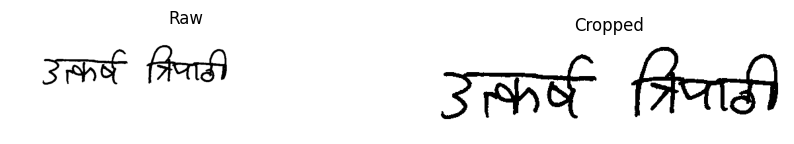

Sample: W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\BHSig260\BHSig260-Hindi\39\H-S-39-G-06.tif
Raw shape: (284, 977) Cropped shape: (133, 534)


In [35]:
# Pick a random example
sample_path = valid_bhsig.sample(1, random_state=7)["path"].iloc[0]
raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
cropped = crop_to_ink(raw)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Raw"); plt.imshow(raw, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Cropped"); plt.imshow(cropped, cmap="gray"); plt.axis("off")
plt.show()

print("Sample:", sample_path)
print("Raw shape:", raw.shape, "Cropped shape:", cropped.shape)

In [36]:
def make_pair_dataset(pairs_df, batch_size=32, shuffle=True):
    a_paths = pairs_df["path_a"].astype(str).values
    b_paths = pairs_df["path_b"].astype(str).values
    labels  = pairs_df["label"].astype(np.float32).values

    ds = tf.data.Dataset.from_tensor_slices((a_paths, b_paths, labels))

    def map_fn(a, b, y):
        img_a = tf_load_preprocess(a)
        img_b = tf_load_preprocess(b)
        return (img_a, img_b), y

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(4000, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pair_dataset(train_pairs, batch_size=32, shuffle=True)
val_ds   = make_pair_dataset(val_pairs,   batch_size=32, shuffle=False)
test_ds  = make_pair_dataset(test_pairs,  batch_size=32, shuffle=False)

(batch_x, batch_y) = next(iter(train_ds))
print(batch_x[0].shape, batch_x[1].shape, batch_y.shape)
print("Batch label counts:", np.unique(batch_y.numpy(), return_counts=True))

(32, 224, 224, 1) (32, 224, 224, 1) (32,)
Batch label counts: (array([0., 1.], dtype=float32), array([14, 18]))


In [37]:
EMB_DIM = 128

def build_embedding_network(input_shape=(224,224,1), emb_dim=128):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    emb = layers.Dense(emb_dim)(x)

    # IMPORTANT: avoid Lambda issues by using a small custom layer
    emb = layers.LayerNormalization(name="emb_ln")(emb)
    emb = layers.Lambda(
        lambda t: tf.nn.l2_normalize(t, axis=1),
        output_shape=(emb_dim,),
        name="l2_norm"
    )(emb)

    return keras.Model(inp, emb, name="embedding_net")

embedding_net = build_embedding_network(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
    emb_dim=EMB_DIM
)
embedding_net.summary()

Model: "embedding_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emb_ln (LayerNormalization)     │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (Lambda)                │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,784 (1.86 MB)

 Trainable params: 486,784 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
class SquaredEuclidean(layers.Layer):
    def call(self, inputs):
        a, b = inputs
        return tf.reduce_sum(tf.square(a - b), axis=1, keepdims=True)

def build_siamese_model(embedding_model, input_shape=(224,224,1)):
    a = keras.Input(shape=input_shape, name="img_a")
    b = keras.Input(shape=input_shape, name="img_b")
    emb_a = embedding_model(a)
    emb_b = embedding_model(b)
    dist = SquaredEuclidean(name="sq_euclidean")([emb_a, emb_b])
    return keras.Model([a, b], dist, name="siamese_network")

siamese_model = build_siamese_model(
    embedding_net,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)
)
siamese_model.summary()

Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_a (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_b (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_net       │ (None, 128)       │    486,784 │ img_a[0][0],      │
│ (Functional)        │                   │            │ img_b[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sq_euclidean        │ (None, 1)         │          0 │ embedding_net[0]… │
│ (SquaredEuclidean)  │                   │            │ embedding_net[1]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 486,784 (1.86 MB)

 Trainable params: 486,784 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
class ContrastiveLoss(keras.losses.Loss):
    def __init__(self, margin=0.5, name="contrastive_loss"):
        super().__init__(name=name)
        self.margin = margin

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        d = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        pos = y_true * tf.square(d)
        neg = (1.0 - y_true) * tf.square(tf.maximum(self.margin - d, 0.0))
        return tf.reduce_mean(pos + neg)

loss_fn = ContrastiveLoss(margin=0.5)

save_dir = r"W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260\baseline_cropink"
os.makedirs(save_dir, exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(save_dir, "best_bhsig_cropink_siamese.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss_fn
)

history = siamese_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# Save full models
siamese_model.save(os.path.join(save_dir, "bhsig_cropink_siamese.keras"))
embedding_net.save(os.path.join(save_dir, "bhsig_cropink_embedding.keras"))

# Save weights ONLY (most reliable for reloading later)
siamese_model.save_weights(os.path.join(save_dir, "bhsig_cropink_siamese.weights.h5"))
embedding_net.save_weights(os.path.join(save_dir, "bhsig_cropink_embedding.weights.h5"))

print("Saved to:", save_dir)

Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - loss: 0.0658
Epoch 1: val_loss improved from None to 0.06209, saving model to W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260\baseline_cropink\best_bhsig_cropink_siamese.keras

Epoch 1: finished saving model to W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260\baseline_cropink\best_bhsig_cropink_siamese.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1913s 757ms/step - loss: 0.0608 - val_loss: 0.0621 - learning_rate: 5.0000e-04
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - loss: 0.0319
Epoch 2: val_loss improved from 0.06209 to 0.02300, saving model to W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260\baseline_cropink\best_bhsig_cropink_siamese.keras

Epoch 2: finished saving model to W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260\baseline_cropink\best_bhsig_cropink_siamese.keras
2500/2500 ━━━━━━━━━━━

In [40]:
def get_distances(model, ds):
    d_all, y_all = [], []
    for (x, y) in ds:
        d = model.predict(x, verbose=0).reshape(-1)
        d_all.append(d)
        y_all.append(y.numpy().reshape(-1))
    return np.concatenate(d_all), np.concatenate(y_all)

def compute_far_frr(d, y, thresholds):
    y = y.astype(int)
    neg = (y == 0)
    pos = (y == 1)
    far, frr = [], []
    for t in thresholds:
        far.append(np.mean(d[neg] <= t))
        frr.append(np.mean(d[pos] >  t))
    return np.array(far), np.array(frr)

val_d, val_y = get_distances(siamese_model, val_ds)

# More stable threshold sweep (better than linspace)
thresholds = np.quantile(val_d, np.linspace(0, 1, 1000))
thresholds = np.unique(thresholds)

far, frr = compute_far_frr(val_d, val_y, thresholds)

eer_idx = np.argmin(np.abs(far - frr))
eer = (far[eer_idx] + frr[eer_idx]) / 2
best_t = thresholds[eer_idx]

print("BHSig Validation EER:", float(eer))
print("Best threshold:", float(best_t))
print("FAR@EER:", float(far[eer_idx]), "FRR@EER:", float(frr[eer_idx]))

BHSig Validation EER: 0.1099
Best threshold: 0.14784943988850646
FAR@EER: 0.1094 FRR@EER: 0.1104


In [41]:
test_d, test_y = get_distances(siamese_model, test_ds)
test_y = test_y.astype(int)

neg = (test_y == 0)
pos = (test_y == 1)

test_far = np.mean(test_d[neg] <= best_t)
test_frr = np.mean(test_d[pos] >  best_t)
test_avg = (test_far + test_frr) / 2

print("BHSig Test FAR (val threshold):", float(test_far))
print("BHSig Test FRR (val threshold):", float(test_frr))
print("BHSig Test avg error:", float(test_avg))

BHSig Test FAR (val threshold): 0.0784
BHSig Test FRR (val threshold): 0.0866
BHSig Test avg error: 0.08249999999999999


In [44]:
save_dir = r"W:\SRH study\Case Study 2\Offline Signature Verification\src\embeddings\BHSig260"

siamese_model.save(os.path.join(save_dir, "bhsig_cropink_siamese.keras"))
embedding_net.save(os.path.join(save_dir, "bhsig_cropink_embedding.keras"))